# Pitch Estimation with Self-Supervised Equivariant Learning 

**Equivariant SSL** is an exciting area of research within the field of MIR and has been **applied successfully to a growing number of tasks in MIR**. Such as tempo, pitch and key estimation. This notebook walks through a **simplified implementation of PESTO, a self-supervised model for pitch estimation** [1].

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://github.com/smilo7/Equivariant-SSL-Tutorial/blob/main/mtg_pre_icassp_workshop_tutorial.ipynb)

### Key Concept
The key idea presented by this approach is rather than labelling audio with pitch values and using a supervised learning model, we pursue a self-supervised approach by exploiting a physical property of the Constant-Q Transform (CQT): **a pitch shift in audio corresponds to a translation in CQT bins**. 

We train a model to be *equivariant* to this translation, meaning its output shifts predictably when the input shifts. From this the model is able to learn to predict relative pitch. Absolute pitch labels can then be easily recovered thereafter.

### Notebook structure
1. Imports & config
2. Data loading
3. Feature extraction (CQT)
4. Transforms and Augmentations
5. Losses
6. Model
7. Training & Relative Pitch Calibration
8. Inference
8. Embedding Visualisation

### References

We encourage you to check out the [original implementation](https://github.com/SonyCSLParis/pesto-full) from which this notebook is based and the paper [1].

[1] A. Riou, “PESTO: Real‑Time Pitch Estimation with Self‑Supervised Transposition‑Equivariant Objective”, <i>Transactions of the International Society for Music Information Retrieval</i>, vol. 8, no. 1, p. 334–352, 2025, doi: [10.5334/tismir.251](https://doi.org/10.5334/TISMIR.251).



## 1. Imports & Config

In [11]:
# # Install dependencies (run this cell first if using Google Colab)
# !pip install nnAudio torchaudio mirdata umap-learn sounddevice

In [12]:
import mirdata
import random
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from tqdm import tqdm
from nnAudio.features.cqt import CQT
import hashlib
import json
from pathlib import Path
from typing import Mapping, Optional, Sequence
import logging
import umap
import IPython.display as ipd

In [13]:
# Data / CQT settings
HOP_DURATION        = 10.       # ms
FMIN                = 27.5      # Hz
BINS_PER_SEMITONE   = 3
N_BINS              = 88
CENTER_BINS         = True
BATCH_SIZE          = 256

# Training settings
MAX_EPOCHS          = 50
MAX_STEPS           = BINS_PER_SEMITONE * 11 // 2
MIN_STEPS           = -MAX_STEPS
T_MAX               = MAX_EPOCHS   # for CosineAnnealingLR

# Augmentation settings
MIN_SNR             = 0.1
MAX_SNR             = 2.
P_RANDNOISE         = 0.7
MIN_GAIN            = 0.5
MAX_GAIN            = 1.5
P_RANDGAIN          = 0.7

# Dataloader settings
NUM_WORKERS         = 2
PIN_MEMORY          = True
CACHE_DIR           = "./cache"

# Encoder settings
N_CHAN_INPUT        = 1
N_CHAN_LAYERS       = (40, 30, 30, 10, 3)
N_PREFILT_LAYERS    = 2
PREFILT_KERNEL_SIZE = 15
RESIDUAL            = False
N_BINS_RAW          = 99 * BINS_PER_SEMITONE - 1   # matches original: wider freq range for pitch-shift window
N_BINS_IN           = 88 * BINS_PER_SEMITONE        # encoder input bins, fixed, not derived from MAX_STEPS
OUTPUT_DIM          = 128 * BINS_PER_SEMITONE
A_LRELU             = 0.3
P_DROPOUT           = 0.2

# Optimizer settings
LR                  = 1e-4
WEIGHT_DECAY        = 0.

# Loss weights
LOSS_WEIGHTS        = dict(invariance=0., equivariance=1.0, shift_entropy=0.)
EMA_RATE            = 0.99

# Paths
AUDIO_FILES         = "train_files.csv"
CHECKPOINT_PATH     = "pesto_model_checkpoint.pt"
# Train/test split
TEST_SPLIT          = 0.05   # fraction of tracks held out for inference tests
RANDOM_SEED         = 42

In [14]:
# optionally load from checkpoint instead of training
TRAINING = False

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
log = logging.getLogger(__name__)

## 2. Data Loading

We train on [Vocadito](https://mirdata.readthedocs.io/en/stable/_modules/mirdata/datasets/vocadito.html), a dataset of 40 solo vocal recordings with monophonic pitch annotations.

### Getting the data

You have two options below, choose one, uncomment the code and run the corresponding cell.

### Option A - Download the pre-computed CQT cache (recommended)
Fastest way to get started. Downloads a pre-processed `.pt` file containing log-magnitude CQT frames ready for training and a pre-split list of training files.

In [16]:
# !mkdir cache
# !wget -O cache/cqt_7844b089.pt https://github.com/smilo7/Equivariant-SSL-Tutorial/blob/main/cache/cqt_7844b089.pt
# !wget -O train_files.csv    https://github.com/smilo7/Equivariant-SSL-Tutorial/blob/main/train_files.csv
# !wget -O test_files.csv     https://github.com/smilo7/Equivariant-SSL-Tutorial/blob/main/test_files.csv
# !wget -O pesto_model_checkpoint.pt https://github.com/smilo7/Equivariant-SSL-Tutorial/blob/main/pesto_model_checkpoint.pt

### Option B - Download Vocadito via mirdata and compute from scratch
If you'd like to work from the raw audio, you can download Vocadito directly using `mirdata`. This requires more time and disk space but lets you inspect the raw audio and experiment with different CQT settings.


In [17]:
# download
vocadito = mirdata.initialize('vocadito', data_home='data/vocadito')
vocadito.download()

# get all audio file paths
track_ids = vocadito.track_ids
random.seed(RANDOM_SEED)
random.shuffle(track_ids)

# split by track, avoids any frame-level leakage between train and test
n_test   = max(1, int(len(track_ids) * TEST_SPLIT))
test_ids  = track_ids[:n_test]
train_ids = track_ids[n_test:]

def ids_to_csv(ids, path):
    paths = [vocadito.track(t).audio_path for t in ids]
    Path(path).write_text("\n".join(paths))
    print(f"Wrote {len(paths)} files to {path}")

ids_to_csv(train_ids, "train_files.csv")
ids_to_csv(test_ids,  "test_files.csv")

/home/am/Documents/upf_smc/mir_materials_internship/icassp_tutorial/Equivariant-SSL-Tutorial/.venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Wrote 38 files to train_files.csv
Wrote 2 files to test_files.csv


## 3. Feature Extraction

### Why the CQT?

The Constant-Q Transform uses a logarithmic frequency axis, which means equal musical intervals (e.g. one semitone) correspond to equal distances in bins, regardless of which octave you're in. This is what gives us the property we need: **a pitch shift in audio = a translation in CQT bins**.

In [18]:
class CQTModule(nn.Module):
    def __init__(
            self,
            sr: int = 22050,
            hop_length: int = 512,
            fmin: float = 32.7,
            fmax: float | None = None,
            bins_per_semitone: int = 1,
            n_bins: int = 84,
            center_bins: bool = True
    ):
        super().__init__()

        if center_bins:
            fmin = fmin / 2 ** ((bins_per_semitone - 1) / (24 * bins_per_semitone))

        self.cqt_kernel = CQT(
            sr=sr,
            hop_length=hop_length,
            fmin=fmin,
            fmax=fmax,
            n_bins=n_bins,
            bins_per_octave=12 * bins_per_semitone,
            output_format="Complex",
            verbose=False
        )

    def forward(self, audio: torch.Tensor) -> torch.Tensor:
        """
        Args:
            audio: mono waveform, shape (samples,)
        Returns:
            CQT, shape (time, 1, freq_bins)
        """
        # (1, freq_bins, time, 2) -> (time, 1, freq_bins, 2)
        return self.cqt_kernel(audio).squeeze(0).permute(1, 0, 2).unsqueeze(1)

In [19]:
class ToLogMagnitude(nn.Module):
    def __init__(self):
        super().__init__()
        self.eps = torch.finfo(torch.float32).eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.size(-1) == 2:
            x = torch.view_as_complex(x)
        if x.ndim == 2:
            x = x.unsqueeze(1)
        return x.abs().clamp(min=self.eps).log10().mul(20)

Once you have your data, `AudioDataModule` handles the rest: it computes and caches CQT frames on first run, and loads from cache on subsequent runs. The cache path is keyed by a hash of the CQT config, so changing any parameter automatically triggers recomputation.

In [20]:
class AudioDataModule:
    def __init__(
            self,
            audio_files: str,
            hop_duration: float = 10.,
            fmin: float = 27.5,
            fmax: float | None = None,
            bins_per_semitone: int = 1,
            n_bins: int = 84,
            center_bins: bool = True,
            batch_size: int = 256,
            num_workers: int = 2,
            pin_memory: bool = False,
            cache_dir: str = "./cache",
    ):
        self.audio_files = Path(audio_files)
        self.hop_duration = hop_duration
        self.cqt_kwargs = dict(
            fmin=fmin,
            fmax=fmax,
            bins_per_semitone=bins_per_semitone,
            n_bins=n_bins,
            center_bins=center_bins,
        )
        self.dl_kwargs = dict(
            batch_size=batch_size,
            num_workers=num_workers,
            pin_memory=pin_memory,
        )
        self.cache_dir = Path(cache_dir)

        # expose for downstream use (e.g. inference, shift estimation)
        self.cqt_kwargs = self.cqt_kwargs
        self._cqt_sr: int | None = None
        self._cqt_module: CQTModule | None = None
        self._log_mag = ToLogMagnitude()

        self.dataset: torch.utils.data.TensorDataset | None = None

    # Public API
    def prepare_data(self) -> None:
        tensor = self._load_or_compute()
        self.dataset = torch.utils.data.TensorDataset(tensor)

    def train_dataloader(self) -> torch.utils.data.DataLoader:
        assert self.dataset is not None, "Call prepare_data() first."
        sampler = torch.utils.data.RandomSampler(self.dataset)
        return torch.utils.data.DataLoader(self.dataset, sampler=sampler, **self.dl_kwargs)

    def cqt(self, audio: torch.Tensor, sr: int) -> torch.Tensor:
        """Compute CQT for a single mono waveform. Reuses kernel if sr unchanged."""
        if sr != self._cqt_sr:
            self._cqt_sr = sr
            hop_length = int(self.hop_duration * sr / 1000 + 0.5)
            self._cqt_module = CQTModule(sr=sr, hop_length=hop_length, **self.cqt_kwargs)
        return self._cqt_module(audio)

    # Internal
    def _cache_path(self) -> Path:
        key = json.dumps({
            "audio_files": str(self.audio_files),
            "hop_duration": self.hop_duration,
            **self.cqt_kwargs,
        }, sort_keys=True)
        hash_id = hashlib.sha256(key.encode()).hexdigest()[:8]
        return self.cache_dir / f"cqt_{hash_id}.pt"

    def _load_or_compute(self) -> torch.Tensor:
        cache = self._cache_path()
        if cache.exists():
            log.info(f"Loading CQT cache from {cache}")
            return torch.load(cache, weights_only=True)

        self.cache_dir.mkdir(parents=True, exist_ok=True)
        tensor = self._precompute_cqt()
        torch.save(tensor, cache)
        log.info(f"Saved CQT cache to {cache}")
        return tensor

    def _precompute_cqt(self) -> torch.Tensor:
        audio_files = self.audio_files.read_text().splitlines()
        data_dir = self.audio_files.parent

        chunks = []
        for fname in tqdm(audio_files, desc="Precomputing CQT", leave=False):
            fname = fname.strip()
            if not fname:
                continue
            waveform, sr = torchaudio.load(data_dir / fname)
            cqt = self.cqt(waveform.mean(dim=0), sr)           # (time, 1, freq_bins, 2)
            log_cqt = self._log_mag(torch.view_as_complex(cqt.float()))  # (time, 1, freq_bins)
            chunks.append(log_cqt.cpu())

        return torch.cat(chunks)  

### Load or Calculate CQTs

Depending on whether you picked option A or B above, the below cell will either load or compute a cache of cqt files.

In [21]:
datamodule = AudioDataModule(
    audio_files=AUDIO_FILES,
    hop_duration=HOP_DURATION,
    fmin=FMIN,
    bins_per_semitone=BINS_PER_SEMITONE,
    n_bins=N_BINS_RAW,
    center_bins=CENTER_BINS,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    cache_dir=CACHE_DIR,
)
datamodule.prepare_data()
print(f"Dataset size: {len(datamodule.dataset)} frames")

INFO: Loading CQT cache from cache/cqt_7844b089.pt


Dataset size: 77304 frames


/home/am/Documents/upf_smc/mir_materials_internship/icassp_tutorial/Equivariant-SSL-Tutorial/.venv/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


## 4. Transforms and Augmentations

As discussed in the key concept section in the introduction, fundemental to this equivariant SSL approach for pitch tracking is creating alternative views of data based on a simple crop on a CQT to simulate a change in pitch.

### Pitch-shift augmentation

`PitchShiftCQT` takes a batch of CQT frames and returns:
- `x`: the original crop
- `x_t`: the same frames but shifted by a random `n` bins
- `n_steps`: the shift amount for each item in the batch

The shift is implemented by cropping, we compute the full CQT and then take two different sub-windows along the frequency axis.

<p align="center">
  <img src="figures/cqt_diagram.png" width="40%"><br>
  <em>Figure 1: Shows the diagram from the PESTO paper [1], given a 1D CQT frame you can crop it to create pitch shifted views.</em>
</p>

In [22]:
class PitchShiftCQT(nn.Module):
    def __init__(self, min_steps: int, max_steps: int):
        super().__init__()
        self.min_steps = min_steps
        self.max_steps = max_steps
        self.lower_bin = self.max_steps

    def forward(self, spectrograms: torch.Tensor):
        batch_size, _, input_height = spectrograms.size()
        output_height = input_height - self.max_steps + self.min_steps
        assert output_height > 0

        n_steps = torch.randint(self.min_steps, self.max_steps + 1, (batch_size,), device=spectrograms.device)
        x = spectrograms[..., self.lower_bin: self.lower_bin + output_height]
        xt = self.extract_bins(spectrograms, self.lower_bin - n_steps, output_height)
        return x, xt, n_steps

    def extract_bins(self, inputs: torch.Tensor, first_bin: torch.LongTensor, output_height: int):
        indices = first_bin.unsqueeze(-1) + torch.arange(output_height, device=inputs.device)
        dims = inputs.size(0), 1, output_height
        output_size = list(inputs.size())[:-1] + [output_height]
        indices = indices.view(*dims).expand(output_size)
        return inputs.gather(-1, indices)


Let's visualise what `PitchShiftCQT` is doing on a single frame of our pre-processed dataset.

Shift steps: 6
Original shape: (286,)
Shifted shape: (291,)


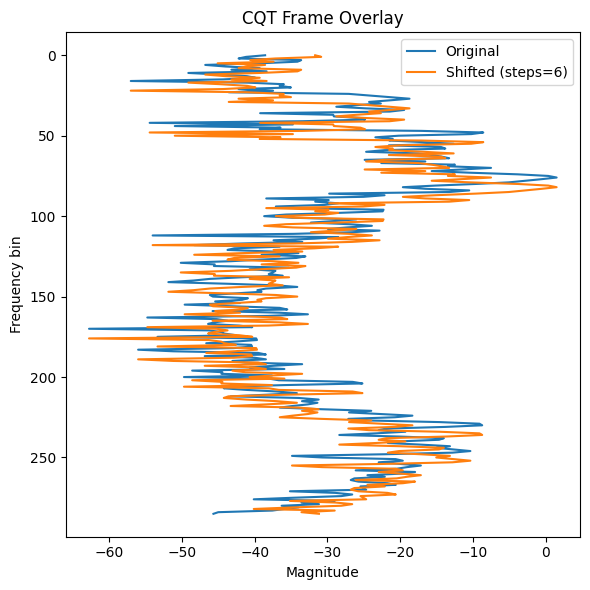

In [23]:
def get_random_frame_and_shift(datamodule, pitch_shift_module, device="cpu"):
    dataset = datamodule.dataset
    assert dataset is not None

    # Pick random index
    idx = random.randint(0, len(dataset) - 1)

    frame = dataset[idx][0].to(device)  # (1, freq_bins)

    # Add batch dim → (1, 1, freq_bins)
    frame = frame.unsqueeze(0)

    # Apply pitch shift
    x, xt, n_steps = pitch_shift_module(frame)

    # Remove batch/channel dims
    x = x.squeeze().cpu().numpy()
    xt = xt.squeeze().cpu().numpy()

    return x, xt, n_steps.item()

def plot_overlay(original, shifted, steps):
    # Align lengths
    min_len = min(len(original), len(shifted))
    original = original[:min_len]
    shifted = shifted[:min_len]

    freq_axis = range(min_len)

    plt.figure(figsize=(6, 6))
    plt.plot(original, freq_axis, label="Original")
    plt.plot(shifted, freq_axis, label=f"Shifted (steps={steps})")
    plt.gca().invert_yaxis()  # frequency up
    plt.xlabel("Magnitude")
    plt.ylabel("Frequency bin")
    plt.title("CQT Frame Overlay")
    plt.legend()
    plt.tight_layout()
    plt.show()


pitch_shift = PitchShiftCQT(min_steps=5, max_steps=10)

x, xt, steps = get_random_frame_and_shift(datamodule, pitch_shift)

print("Shift steps:", steps)
print("Original shape:", x.shape)
print("Shifted shape:", xt.shape)

plot_overlay(x, xt, steps)

### Pitch invariant augmentations

We implement two pitch invariant augmentations to help the robustness of the learned representation, **random noise** and **random gain**.

In [24]:
class BatchRandomNoise(nn.Module):
    def __init__(self, min_snr: float = 0.0001, max_snr: float = 0.01, p: Optional[float] = None):
        super().__init__()
        self.min_snr = min_snr
        self.max_snr = max_snr
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        device = x.device
        snr = torch.empty(batch_size, device=device).uniform_(self.min_snr, self.max_snr)
        mask = torch.rand_like(snr).le(self.p)
        snr[mask] = 0
        noise_std = snr * x.view(batch_size, -1).std(dim=-1)
        noise_std = noise_std.unsqueeze(-1).expand_as(x.view(batch_size, -1)).view_as(x)
        return x + noise_std * torch.randn_like(x)


class BatchRandomGain(nn.Module):
    def __init__(self, min_gain: float = 0.5, max_gain: float = 1.5, p: Optional[float] = None):
        super().__init__()
        self.min_gain = min_gain
        self.max_gain = max_gain
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        device = x.device
        vol = torch.empty(batch_size, device=device).uniform_(self.min_gain, self.max_gain)
        mask = torch.rand_like(vol).le(self.p)
        vol[mask] = 1
        vol = vol.unsqueeze(-1).expand_as(x.view(batch_size, -1)).view_as(x)
        return vol * x

## 5. Losses

PESTO uses three losses, each enforcing a different property on the encoder's output distribution. 

First we define a small wrapper (`CrossEntropyLoss`) below around PyTorch's cross entropy that both the invariance loss and shift cross entropy equivariance loss below build on.

In [25]:
class CrossEntropyLoss(nn.Module):
    def __init__(self, symmetric=False, detach_targets=False, backend=nn.CrossEntropyLoss()):
        super().__init__()
        self.symmetric = symmetric
        self.detach_targets = detach_targets
        self.backend = backend

    def forward(self, input, target):
        if self.symmetric:
            return (self.compute_loss(input, target) + self.compute_loss(target, input)) / 2
        return self.compute_loss(input, target)

    def compute_loss(self, input, target):
        return self.backend(input, target.detach() if self.detach_targets else target)

### Loss 1: Equivariance - ShiftCrossEntropy

This is the primary equivariance loss. Given a pair of CQT frames (`x1`, `x2`) where `x2` is a pitch-shifted version of `x1` by a known `n` bins, the encoder should output distributions that are shifted by the same `n` number of pitch bins. No pitch labels are needed, only the relative shift between the two frames.

We enforce this by padding both output distributions and aligning them by `n` before computing cross entropy. If the model is truly equivariant, the aligned distributions should match.

In [26]:
class ShiftCrossEntropy(nn.Module):
    """Equivariance loss: the output distribution should translate by n bins
    when the input CQT is shifted by n bins.
    """
    def __init__(self, pad_length=5, criterion=CrossEntropyLoss()):
        super().__init__()
        self.criterion = criterion
        self.pad_length = pad_length

    def forward(self, x1, x2, target):
        x1 = F.pad(x1, (self.pad_length, self.pad_length))
        x2 = F.pad(x2, (2*self.pad_length, 2*self.pad_length))
        idx = target.unsqueeze(1) + torch.arange(x1.size(-1), device=target.device) + self.pad_length
        shift_x2 = torch.gather(x2, dim=1, index=idx)
        return self.criterion(x1, shift_x2)


### Loss 2: Equivariance - PowerSeries

`ShiftCrossEntropy` treats bins as evenly-spaced integers. `PowerSeries` enforces equivariance in frequency space instead, which is a stricter and more physically motivated constraint.

The key idea: if the input is pitch-shifted by `n` semitones, the true frequency ratio between the two frames is $r = 2^{n/12}$. The loss projects each output distribution down to a scalar using a geometric (power series) weighting, then penalises deviations from the expected ratio $z_2 / z_1 = r$.

The penalty uses a **Huber loss** rather than squared error, this makes it robust to the occasional badly shifted or ambiguous frame, which would otherwise produce large outlier gradients.

The loss is computed symmetrically in both directions ($z_2/z_1$ and $z_1/z_2$) and averaged.

In [27]:
class PowerSeries(nn.Module):
    """Equivariance loss: a scalar projection of the output should scale
    by the correct frequency ratio when the input is pitch-shifted.
    """
    def __init__(self, value: float, power_min, power_max, tau: float = 1.):
        super().__init__()
        self.value = value
        self.tau = tau
        powers = torch.arange(power_min, power_max)
        self.register_buffer("weights", self.value ** powers, persistent=False)

    def forward(self, x1, x2, target, nlog_c1=None, nlog_c2=None):
        z1 = self.project(x1)
        z2 = self.project(x2)
        if nlog_c1 is not None:
            z1 = z1 * torch.exp(-nlog_c1)
        if nlog_c2 is not None:
            z2 = z2 * torch.exp(-nlog_c2)
        freq_ratios = self.value ** target.float()
        loss_12 = self._huber(z2 / z1 - freq_ratios).mean()
        loss_21 = self._huber(z1 / z2 - 1/freq_ratios).mean()
        return (loss_12 + loss_21) / 2

    def _huber(self, x):
        x = x.abs()
        return torch.where(x <= self.tau, x ** 2 / 2, self.tau ** 2 / 2 + self.tau * (x - self.tau))

    def project(self, x):
        return x.mv(self.weights)

### Loss 3: Invariance

The equivariance losses train the model on pitch-shifted pairs (`ya` and `yt`), but a model could satisfy them while remaining sensitive to irrelevant variation like background noise or loudness changes. The invariance loss addresses this: we take a frame (`y`) and an augmented version (`ya`) (random noise, random gain, defined in Section 4) and enforce that the encoder outputs an identical distribution for both. This follows the same principle as contrastive SSL methods like SimCLR or BYOL.

It uses the same `CrossEntropyLoss` wrapper, but here no alignment is needed, the two distributions should simply match exactly, since the pitch content hasn't changed.

`symmetric=True` means the loss is computed in both directions and averaged, so neither view (original or augmented) is treated as the fixed target. `detach_targets=True` stops gradients flowing through the target distribution, following the asymmetric trick from BYOL to prevent representation collapse.

In [28]:
class InvarianceLoss(CrossEntropyLoss):
    """Enforces that the encoder output is identical for a frame and its acoustic augmentation.
    Symmetric so neither view is privileged; targets are detached to prevent collapse.
    """
    def __init__(self):
        super().__init__(symmetric=True, detach_targets=True)

### Balancing the losses

Naively summing the losses with fixed weights can cause one loss to dominate training if its gradients are much larger than the others. `GradientsLossWeighting` addresses this by dynamically re-weighting each loss according to the norm of the gradients it produces at the encoder's last layer.

At each step, the gradient norm for each loss is computed and smoothed with an exponential moving average (controlled by `ema_rate`). The weights are then updated so that losses producing larger gradients are down-weighted, keeping the overall training signal balanced.

Note: the commented print statements at the bottom of the class are useful to uncomment if you want to inspect how the weights evolve during training.

In [29]:
class GradientsLossWeighting:
    def __init__(self, weights: Mapping[str, float], ema_rate: float = 0.):
        self.weights = weights
        self.last_layer = None
        self.ema_rate = ema_rate
        self.grads = {k: 1-v for k, v in weights.items()}
        self.weights_tensor = None

    def setup(self, device):
        self.weights_tensor = torch.zeros(len(self.weights.keys()), device=device)

    def combine_losses(self, **losses):
        self.update_weights(losses)
        return sum(self.weights[k] * losses[k] for k in self.weights)

    def update_weights(self, losses):
        for i, (k, loss) in enumerate(losses.items()):
            if not loss.requires_grad:
                return
            grads = torch.autograd.grad(loss, self.last_layer, retain_graph=True)[0].norm().detach()
            old_grads = self.grads[k]
            if old_grads is not None:
                grads = self.ema_rate * old_grads + (1 - self.ema_rate) * grads
            self.grads[k] = grads
            self.weights_tensor[i] = grads

        self.weights_tensor = 1 - self.weights_tensor / self.weights_tensor.sum().clip(min=1e-7)
        for i, k in enumerate(losses.keys()):
            self.weights[k] = self.weights_tensor[i]

        # debug
        # print("  grad norms:", {k: f"{v:.4f}" for k, v in zip(losses.keys(), self.weights_tensor)})
        # print("  weights:   ", {k: f"{v:.4f}" for k, v in self.weights.items()})


## 6. Model

### Siamese Architecture

PESTO uses a **Siamese architecture**, a single encoder whose weights are shared across multiple views of the input. During training, three views are passed through the same encoder: the original frame, an augmented version, and a pitch-shifted version.

The encoder (`Resnet1d`) takes a single CQT frame of shape `(1, freq_bins)` and outputs a probability distribution over `output_dim` pitch bins via a final softmax.

### ToeplitzLinear

The final projection layer is implemented as a `ToeplitzLinear` rather than a standard `nn.Linear`. A Toeplitz matrix has the property that each diagonal is constant, equivalently, it is a convolution. This means the projection from frequency bins to output bins shares weights in a translation-equivariant way, which is exactly the property we want to preserve all the way to the output: a shift in the input should produce a shift in the output, not an arbitrary remapping.

It is implemented as a `nn.Conv1d` with a kernel wide enough to cover the full input-to-output mapping in a single convolution.

In [30]:
class ToeplitzLinear(nn.Conv1d):
    def __init__(self, in_features, out_features):
        super().__init__(
            in_channels=1,
            out_channels=1,
            kernel_size=in_features+out_features-1,
            padding=out_features-1,
            bias=False
        )

    def forward(self, input):
        return super().forward(input.unsqueeze(-2)).squeeze(-2)

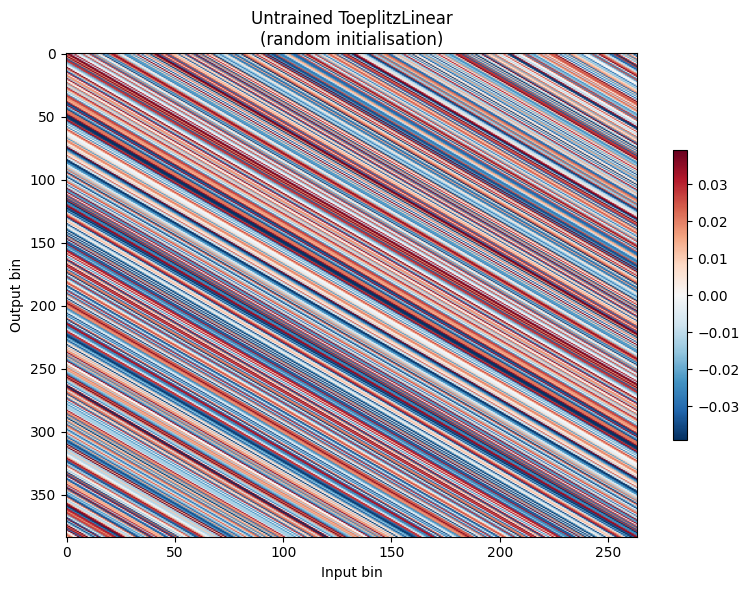

In [31]:
def kernel_to_toeplitz(kernel, in_features, out_features):
    """Reconstruct the implicit Toeplitz weight matrix from a Conv1d kernel vector."""
    W = np.zeros((out_features, in_features))
    for i in range(out_features):
        for j in range(in_features):
            k_idx = j - i + out_features - 1
            if 0 <= k_idx < len(kernel):
                W[i, j] = kernel[k_idx]
    return W

# untrained matrix — fresh random initialisation, same dimensions
untrained_fc     = ToeplitzLinear(N_BINS_IN, OUTPUT_DIM)
untrained_kernel = untrained_fc.weight.data.squeeze().cpu().numpy()
W_untrained      = kernel_to_toeplitz(untrained_kernel, N_BINS_IN, OUTPUT_DIM)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(W_untrained, aspect='auto', cmap='RdBu_r')
plt.colorbar(im, ax=ax, shrink=0.6)
ax.set_xlabel('Input bin')
ax.set_ylabel('Output bin')
ax.set_title('Untrained ToeplitzLinear\n(random initialisation)')
plt.tight_layout()
plt.show()

### Resnet1d Encoder

In [32]:
class Resnet1d(nn.Module):
    def __init__(self,
                 n_chan_input=1,
                 n_chan_layers=(20, 20, 10, 1),
                 n_prefilt_layers=1,
                 prefilt_kernel_size=15,
                 residual=False,
                 n_bins_in=216,
                 output_dim=128,
                 a_lrelu=0.3,
                 p_dropout=0.2):
        super().__init__()

        activation_layer = partial(nn.LeakyReLU, negative_slope=a_lrelu)
        n_in = n_chan_input
        n_ch = n_chan_layers

        self.layernorm = nn.LayerNorm(normalized_shape=[n_in, n_bins_in])
        prefilt_padding = prefilt_kernel_size // 2
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_in, n_ch[0], prefilt_kernel_size, padding=prefilt_padding),
            activation_layer(),
            nn.Dropout(p=p_dropout)
        )
        self.n_prefilt_layers = n_prefilt_layers
        self.prefilt_layers = nn.ModuleList(*[
            nn.Sequential(
                nn.Conv1d(n_ch[0], n_ch[0], prefilt_kernel_size, padding=prefilt_padding),
                activation_layer(),
                nn.Dropout(p=p_dropout)
            )
            for _ in range(n_prefilt_layers-1)
        ])
        self.residual = residual

        conv_layers = []
        for i in range(len(n_chan_layers)-1):
            conv_layers.extend([
                nn.Conv1d(n_ch[i], n_ch[i+1], kernel_size=1),
                activation_layer(),
                nn.Dropout(p=p_dropout)
            ])
        self.conv_layers = nn.Sequential(*conv_layers)

        self.flatten = nn.Flatten(start_dim=1)
        self.fc = ToeplitzLinear(n_bins_in * n_ch[-1], output_dim)
        self.final_norm = nn.Softmax(dim=-1)

    def forward(self, x):
        x = self.layernorm(x)
        x = self.conv1(x)
        for p in range(self.n_prefilt_layers - 1):
            prefilt_layer = self.prefilt_layers[p]
            x = x + prefilt_layer(x) if self.residual else prefilt_layer(x)
        x = self.conv_layers(x)
        x = self.flatten(x)
        return self.final_norm(self.fc(x))

### Argmax-Local Weighted Average (ALWA)

In [33]:
def reduce_activations(activations: torch.Tensor) -> torch.Tensor:
    """Argmax-local weighted averaging (ALWA), converts activation distribution to pitch in MIDI."""
    device = activations.device
    num_bins = activations.size(1)
    bps = num_bins // 128  # bins per semitone

    # MIDI pitch value for every bin, e.g. bin 0 -> MIDI 0.0, bin 1 -> MIDI 0.33 (for bps=3)
    all_pitches = torch.arange(num_bins, dtype=torch.float, device=device).div_(bps)

    # find the peak bin for each item in the batch
    center_bin = activations.argmax(dim=1, keepdim=True)

    # build a local window of width 2*bps (one semitone either side of peak)
    window = torch.arange(1, 2 * bps, device=device) - bps
    indices = (window + center_bin).clip_(min=0, max=num_bins - 1)

    # gather activations and pitch values within the window
    cropped_activations = activations.gather(1, indices)
    cropped_pitches = all_pitches.unsqueeze(0).expand_as(activations).gather(1, indices)

    # normalised weighted average -> sub-bin MIDI pitch estimate
    return (cropped_activations * cropped_pitches).sum(dim=1) / cropped_activations.sum(dim=1)

### PESTO

`PESTO` is the top-level module that wraps the encoder together with the pitch-shift transform, augmentations, and loss functions.

`training_step` is where all three views are constructed and the losses computed, this is the method called inside the training loop. `forward` is the inference path: it applies a single pitch shift crop, runs the encoder, and converts activations to a MIDI pitch estimate via ALWA, optionally correcting for the learned absolute pitch offset `self.shift` (calibrated in Section 8).

<p align="center">
  <img src="figures/model_diagram.png" width="80%"><br>
  <em>Figure 2: Shows an overview of the PESTO model from [1]. First, 1D CQT frames are cropped to create pitch shifted views. Next, pitch preserving augmentations are applied (noise and gain transforms). The siamese style encoder then predicts pitch distributions from the different views and is trained with an invariance loss and equivariance losses.</em>
</p>

In [34]:
class PESTO(nn.Module):
    def __init__(self,
                 encoder: nn.Module,
                 equiv_loss_fn=None,
                 sce_loss_fn=None,
                 inv_loss_fn=None,
                 pitch_shift_kwargs=None,
                 transforms: Sequence[nn.Module] | None = None):
        super().__init__()
        self.encoder = encoder
        self.equiv_loss_fn = equiv_loss_fn
        self.sce_loss_fn = sce_loss_fn
        self.inv_loss_fn = inv_loss_fn
        self.pitch_shift = PitchShiftCQT(**(pitch_shift_kwargs or {}))
        self.transforms = nn.Sequential(*transforms) if transforms is not None else nn.Identity()
        self.register_buffer('shift', torch.zeros((), dtype=torch.float), persistent=True)

    def forward(self, x: torch.Tensor, shift: bool = True) -> torch.Tensor:
        x, *_ = self.pitch_shift(x)
        preds = reduce_activations(self.encoder(x))
        if shift:
            preds.sub_(self.shift)
        return preds

    def training_step(self, x, loss_weighting):
        x, xt, n_steps = self.pitch_shift(x)
        xa = self.transforms(x.clone())
        xt = self.transforms(xt)

        y  = self.encoder(x)   # original (unaugmented, pitch-shifted)
        ya = self.encoder(xa)  # augmented version of x  (noise + gain)
        yt = self.encoder(xt)  # pitch-shifted version, also augmented

        inv_loss          = self.inv_loss_fn(y, ya)
        shift_entropy_loss = self.sce_loss_fn(ya, yt, n_steps)
        equiv_loss        = self.equiv_loss_fn(ya, yt, n_steps)

        total_loss = loss_weighting.combine_losses(
            invariance=inv_loss, shift_entropy=shift_entropy_loss, equivariance=equiv_loss
        )
        return total_loss, dict(invariance=inv_loss, equivariance=equiv_loss,
                                shift_entropy=shift_entropy_loss, loss=total_loss)

## 7. Training

The training loop wires together all the components we have built. Each batch is passed to `training_step`, which handles pitch shifting, augmentation, the three forward passes, and loss computation internally. The learning rate follows a cosine annealing schedule over `MAX_EPOCHS`.

### Initialise everything

In [35]:
encoder = Resnet1d(
    n_chan_input=N_CHAN_INPUT,
    n_chan_layers=list(N_CHAN_LAYERS),
    n_prefilt_layers=N_PREFILT_LAYERS,
    prefilt_kernel_size=PREFILT_KERNEL_SIZE,
    residual=RESIDUAL,
    n_bins_in=N_BINS_IN,
    output_dim=OUTPUT_DIM,
    a_lrelu=A_LRELU,
    p_dropout=P_DROPOUT
)

equiv_loss = PowerSeries(value=2**(1/36), power_min=1-OUTPUT_DIM, power_max=1, tau=2**(1/6)-1)
inv_loss   = InvarianceLoss()
sce_loss   = ShiftCrossEntropy(pad_length=MAX_STEPS, criterion=CrossEntropyLoss(symmetric=True, detach_targets=True))

transforms = [
    BatchRandomNoise(min_snr=MIN_SNR, max_snr=MAX_SNR, p=P_RANDNOISE),
    BatchRandomGain(min_gain=MIN_GAIN, max_gain=MAX_GAIN, p=P_RANDGAIN),
]

model = PESTO(
    encoder=encoder,
    equiv_loss_fn=equiv_loss,
    inv_loss_fn=inv_loss,
    sce_loss_fn=sce_loss,
    transforms=transforms,
    pitch_shift_kwargs=dict(min_steps=MIN_STEPS, max_steps=MAX_STEPS),
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX)

loss_weighting = GradientsLossWeighting(weights=LOSS_WEIGHTS, ema_rate=EMA_RATE)
loss_weighting.last_layer = model.encoder.fc.weight
loss_weighting.setup(device)

### Training Loop


In [36]:
if TRAINING:
    train_loader      = datamodule.train_dataloader()
    equiv_loss_log    = []

    for epoch in range(MAX_EPOCHS):
        model.train()
        epoch_equiv_losses = []
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}")

        for x, in pbar:
            x = x.to(device)
            optimizer.zero_grad()
            total_loss, loss_dict = model.training_step(x, loss_weighting)
            total_loss.backward()
            optimizer.step()
            epoch_equiv_losses.append(loss_dict["equivariance"].item())
            pbar.set_postfix(loss=f"{total_loss.item():.4f}")

        scheduler.step()
        epoch_mean = np.mean(epoch_equiv_losses)
        equiv_loss_log.append(epoch_mean)
        print(f"  Epoch {epoch+1:>3}  equiv_loss = {epoch_mean:.5f}")

    torch.save({"state_dict": model.state_dict()}, CHECKPOINT_PATH)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, len(equiv_loss_log) + 1), equiv_loss_log,
            marker='o', markersize=3, linewidth=1.5, color='steelblue')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean equivariance loss')
    ax.set_title('Equivariance loss during training')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    print(f"Loaded model from {CHECKPOINT_PATH}")

Loaded model from pesto_model_checkpoint.pt


### Relative pitch calibration to absolute pitch

The model learns *relative* pitch (equivariance to shifts) but has no guarantee of
predicting *absolute* pitch correctly. We fix this cheaply: run a handful of synthetic
tones of known pitch through the model, measure the median offset, and store it.
At inference time this offset is subtracted from every prediction.

In [37]:
def generate_synth_data(pitch: int, num_harmonics: int = 5, duration: float = 2., sr: int = 16000) -> torch.Tensor:
    """Generate a synthetic harmonic tone for a given MIDI pitch."""
    f0 = 440 * 2 ** ((pitch - 69) / 12)
    t = torch.arange(0, duration, 1/sr)
    harmonics = torch.stack([
        torch.cos(2 * torch.pi * k * f0 * t + torch.rand(()))
        for k in range(1, num_harmonics+1)
    ], dim=1)
    volume = torch.rand(num_harmonics)
    volume[0] = 1
    volume *= torch.randn(())
    return torch.sum(volume * harmonics, dim=1)

In [38]:
def estimate_shift(model: PESTO, datamodule: AudioDataModule, sr: int = 16000) -> None:
    labels = torch.arange(60, 72)
    batch = []
    for p in labels:
        audio = generate_synth_data(p.item(), sr=sr)
        cqt = datamodule.cqt(audio, sr)                                     # (time, 1, freq_bins, 2)
        log_cqt = ToLogMagnitude()(torch.view_as_complex(cqt.float()))      # (time, 1, freq_bins)
        batch.append(log_cqt[0])

    x = torch.stack(batch).to(next(model.parameters()).device)
    with torch.no_grad():
        preds = model(x, shift=False)

    shift = (preds - labels.to(x.device)).median()
    model.shift.fill_(shift)
    print(f"Estimated pitch shift: {shift.item():.3f} semitones")

In [39]:
# load the model checkpoint and test the shift estimation
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["state_dict"])
estimate_shift(model, datamodule)

Estimated pitch shift: 53.333 semitones


## 9. Inference

With the model trained and the absolute pitch offset calibrated in Section 8, we can run inference on any audio. We define two helper functions used throughout this section:

- `run_inference` - computes the log-magnitude CQT, runs the encoder in batches, and returns pitch predictions, raw activations, frame times, and the CQT tensor. The activations are also used in Section 10 for embedding visualisation.
- `plot_predictions` - overlays the predicted pitch contour on the log-magnitude CQT spectrogram.

In [40]:
def run_inference(model, audio_mono, sr, datamodule, device, hop_duration=HOP_DURATION):
    """Compute CQT and run batched PESTO inference on a mono waveform.
    
    Returns:
        pitches:     (T,) numpy array of absolute MIDI pitch predictions
        activations: (T, output_dim) numpy array of raw encoder activations
        times:       (T,) numpy array of frame times in seconds
        cqt:         (T, 1, freq_bins) log-magnitude CQT tensor (on device)
    """
    hop_length = int(hop_duration * sr / 1000 + 0.5)
    cqt_module = CQTModule(sr=sr, hop_length=hop_length, **datamodule.cqt_kwargs)

    with torch.no_grad():
        cqt = ToLogMagnitude()(torch.view_as_complex(cqt_module(audio_mono).float())).to(device)

    all_preds, all_acts = [], []
    with torch.no_grad():
        for start in range(0, len(cqt), BATCH_SIZE):
            x = cqt[start:start + BATCH_SIZE]
            x_cropped, _, _ = model.pitch_shift(x)
            acts  = model.encoder(x_cropped)
            preds = reduce_activations(acts) - model.shift
            all_preds.append(preds)
            all_acts.append(acts)

    pitches     = torch.cat(all_preds).cpu().numpy()
    activations = torch.cat(all_acts).cpu().numpy()
    times       = np.arange(len(pitches)) * hop_length / sr
    return pitches, activations, times, cqt


def plot_predictions(pitches, times, cqt, datamodule, title="PESTO Predictions"):
    """Plot predicted pitch contour overlaid on the log-magnitude CQT."""
    cqt_display = cqt.squeeze().cpu().numpy()
    midi_fmin   = 12 * np.log2(FMIN / 440) + 69
    bps         = datamodule.cqt_kwargs["bins_per_semitone"]
    pitch_bins  = (pitches - midi_fmin) * bps
    valid       = (pitch_bins >= 0) & (pitch_bins < cqt_display.shape[1])

    notes = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(cqt_display.T, aspect="auto", origin="lower", cmap="magma",
              extent=[times[0], times[-1], 0, cqt_display.shape[1]])
    ax.plot(times[valid], pitch_bins[valid], c="cyan", linewidth=1, alpha=0.9, label="Predicted pitch")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pitch")
    ax.set_title(title)
    midi_ticks = np.arange(int(pitches[valid].min()), int(pitches[valid].max()) + 1, 4)
    ax.set_yticks((midi_ticks - midi_fmin) * bps)
    ax.set_yticklabels([f"{notes[int(m)%12]}{int(m)//12-1}" for m in midi_ticks], fontsize=8)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


### Option A: Load from file

Run inference on any mono or stereo audio file note that stereo is averaged to mono before processing.

If you downloaded vocadito earlier, you should be able to leave the code as is otherwise configure the path to a location of your choice.

Running inference on: data/vocadito/Audio/vocadito_12.wav


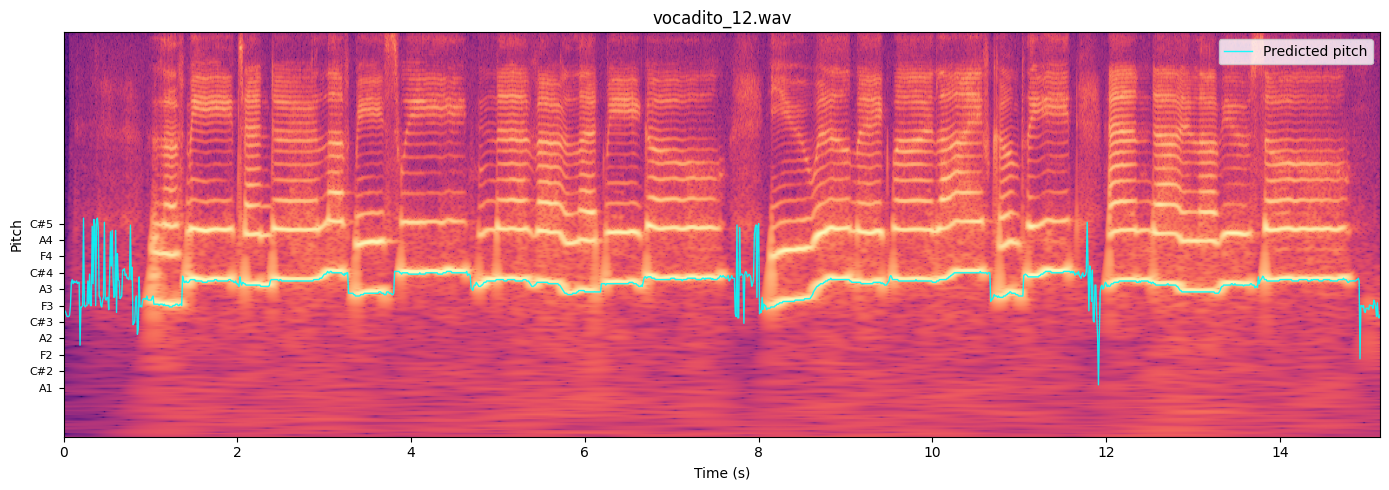

In [41]:
# if you downloaded vocadito from mirdata pick a random file from the held-out test set
test_files = Path("test_files.csv").read_text().splitlines()
audio_path = random.choice(test_files)
print(f"Running inference on: {audio_path}")

# otherwise you can test on any audio file you like by setting audio_path to the path of your chosen file
# audio_path = "data/vocadito/Audio/vocadito_1.wav"

waveform, sr = torchaudio.load(audio_path)
audio_mono   = waveform.mean(dim=0)
pitches, activations, times, cqt = run_inference(model, audio_mono, sr, datamodule, device)
plot_predictions(pitches, times, cqt, datamodule, title=Path(audio_path).name)

In [42]:
# play waveform
ipd.Audio(audio_path)

### Option B: Record from microphone

You can also record directly from your microphone. Try singing some notes! 

Note: This requires `sounddevice` is installed.

In [38]:
# # If running on Google Colab you might need to run this cell for microphone recording to work
# !apt-get install libportaudio2

In [ ]:
import sounddevice as sd

RECORD_SECONDS = 10
SR_MIC         = 22050  # must match a sample rate your CQT kernel supports

print(f"Recording for {RECORD_SECONDS}s...")
recording = sd.rec(int(RECORD_SECONDS * SR_MIC), samplerate=SR_MIC, channels=1, dtype="float32")
sd.wait()
print("Done.")

audio_mono = torch.from_numpy(recording.squeeze())
pitches, activations, times, cqt = run_inference(model, audio_mono, SR_MIC, datamodule, device)
plot_predictions(pitches, times, cqt, datamodule, title="Microphone recording")

## 10. Embedding Visualisation

In this section we will look at several ways to visualise and understand the representation the model has learned.

### Dataset Inference & Embedding Extraction with UMAP

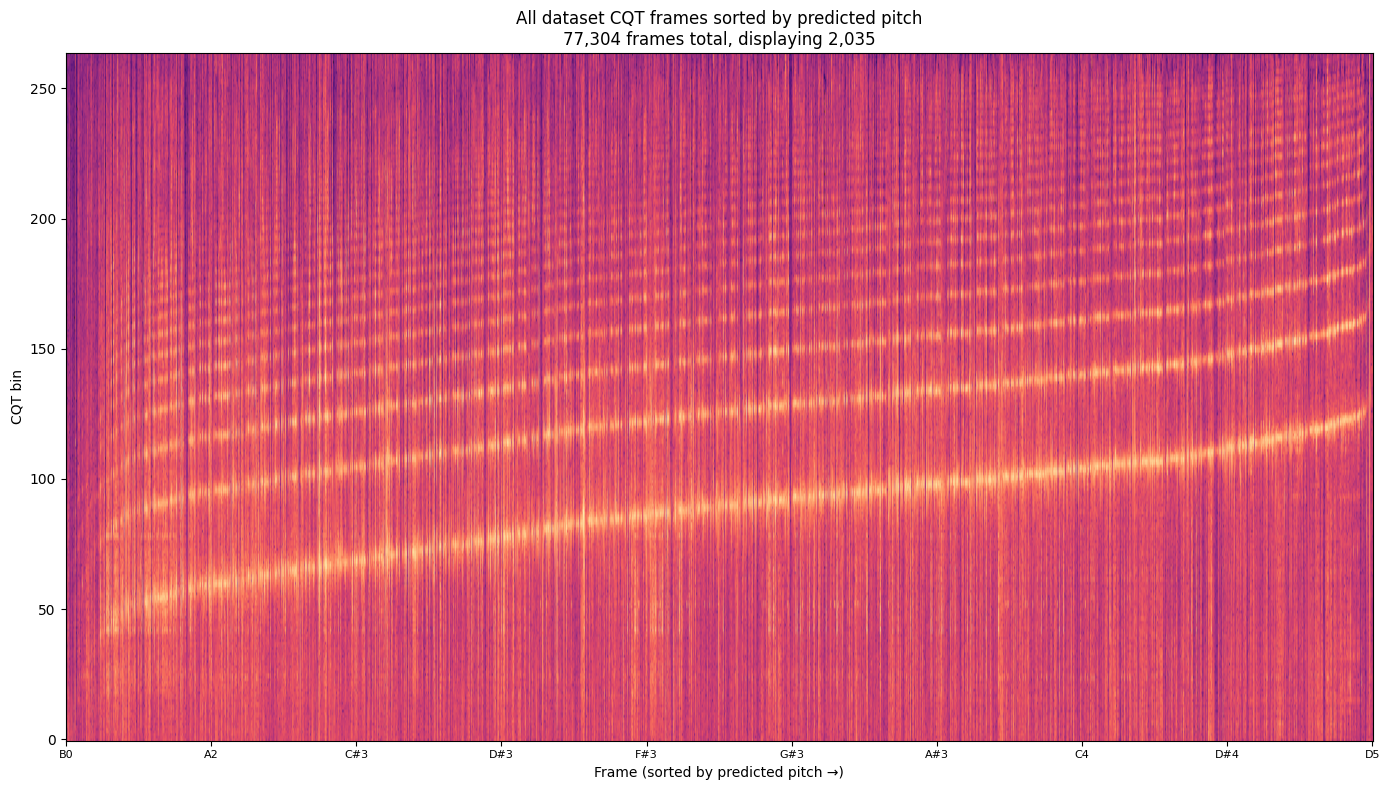

In [42]:
model.eval()

all_frames  = datamodule.dataset.tensors[0].to(device)
all_preds   = []
all_acts    = []
pre_softmax = []

def hook_fn(module, input, output):
    pre_softmax.append(input[0].detach().cpu())

hook = model.encoder.final_norm.register_forward_hook(hook_fn)

with torch.no_grad():
    for start in range(0, len(all_frames), BATCH_SIZE):
        batch           = all_frames[start : start + BATCH_SIZE]
        x_cropped, _, _ = model.pitch_shift(batch)
        acts            = model.encoder(x_cropped)
        preds           = reduce_activations(acts) - model.shift
        all_preds.append(preds.cpu())
        all_acts.append(acts.cpu())

hook.remove()

all_preds   = torch.cat(all_preds).numpy()
all_acts    = torch.cat(all_acts).numpy()
pre_softmax = torch.cat(pre_softmax).numpy()

# sort frames by predicted pitch
sort_idx      = np.argsort(all_preds)
sorted_preds  = all_preds[sort_idx]

lower_bin      = model.pitch_shift.lower_bin
all_frames_cpu = all_frames.cpu()
sorted_frames  = all_frames_cpu[sort_idx, 0, lower_bin : lower_bin + N_BINS_IN].numpy()

MAX_DISPLAY = 2000
if len(sorted_frames) > MAX_DISPLAY:
    step           = len(sorted_frames) // MAX_DISPLAY
    display_frames = sorted_frames[::step]
    display_preds  = sorted_preds[::step]
else:
    display_frames = sorted_frames
    display_preds  = sorted_preds

notes       = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
n_ticks     = 10
tick_pos    = np.linspace(0, len(display_preds) - 1, n_ticks, dtype=int)
tick_midi   = display_preds[tick_pos]
tick_labels = [f"{notes[int(m) % 12]}{int(m) // 12 - 1}" for m in tick_midi]

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(display_frames.T, aspect='auto', origin='lower', cmap='magma')
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_xlabel('Frame (sorted by predicted pitch →)')
ax.set_ylabel('CQT bin')
ax.set_title(f'All dataset CQT frames sorted by predicted pitch\n'
             f'{len(sorted_frames):,} frames total, displaying {len(display_frames):,}')
plt.tight_layout()
plt.show()

Running UMAP on 5000 points...


/home/am/Documents/upf_smc/mir_materials_internship/icassp_tutorial/Equivariant-SSL-Tutorial/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


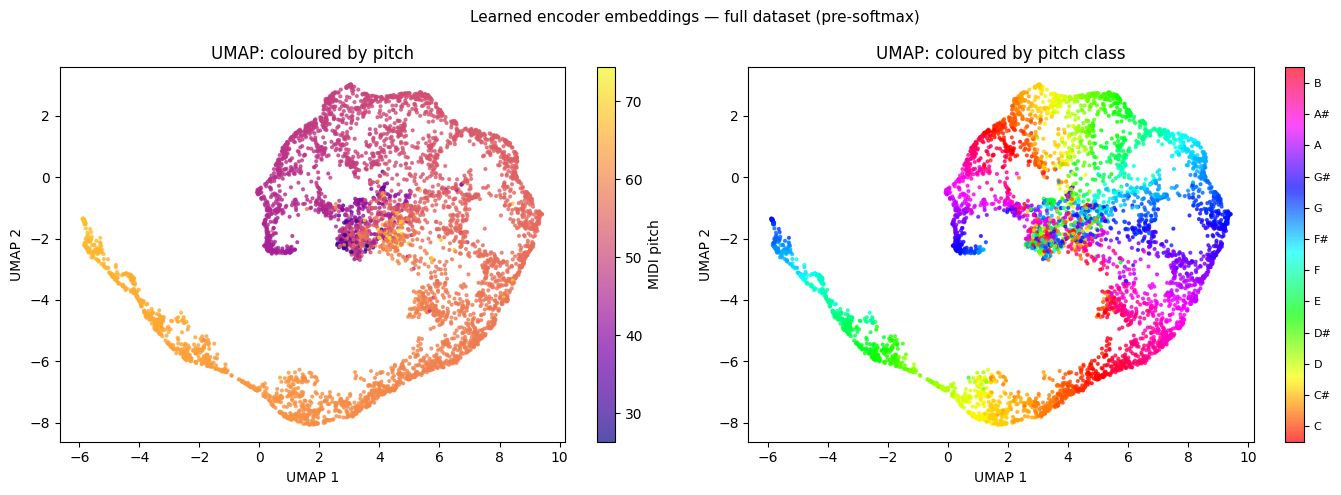

In [ ]:
MAX_POINTS = 5000
if len(pre_softmax) > MAX_POINTS:
    idx          = np.random.choice(len(pre_softmax), MAX_POINTS, replace=False)
    idx.sort()
    emb_sample   = pre_softmax[idx]
    pitch_sample = all_preds[idx]
else:
    emb_sample   = pre_softmax
    pitch_sample = all_preds

reducer = umap.UMAP(n_components=2, random_state=42)
print(f"Running UMAP on {len(emb_sample)} points...")
emb_2d = reducer.fit_transform(emb_sample)

notes       = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
pitch_class = pitch_sample % 12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pitch_sample, cmap="plasma", s=4, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label="MIDI pitch")
axes[0].set_title("UMAP: coloured by pitch")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

sc2 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pitch_class, cmap="hsv", vmin=0, vmax=12, s=4, alpha=0.7)
cbar = plt.colorbar(sc2, ax=axes[1], ticks=np.arange(0.5, 12))
cbar.ax.set_yticklabels(notes, fontsize=8)
axes[1].set_title("UMAP: coloured by pitch class")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.suptitle("Learned encoder embeddings — full dataset (pre-softmax)", fontsize=11)
plt.tight_layout()
plt.savefig("embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

### Embedding similarity matrix

How similar are the encoder outputs for pairs of known pitches?

We can generate synthetic tones, run these through the encoder and compute the cosine similarity between each pair of output distributions. Then plot the result as a heatmap.



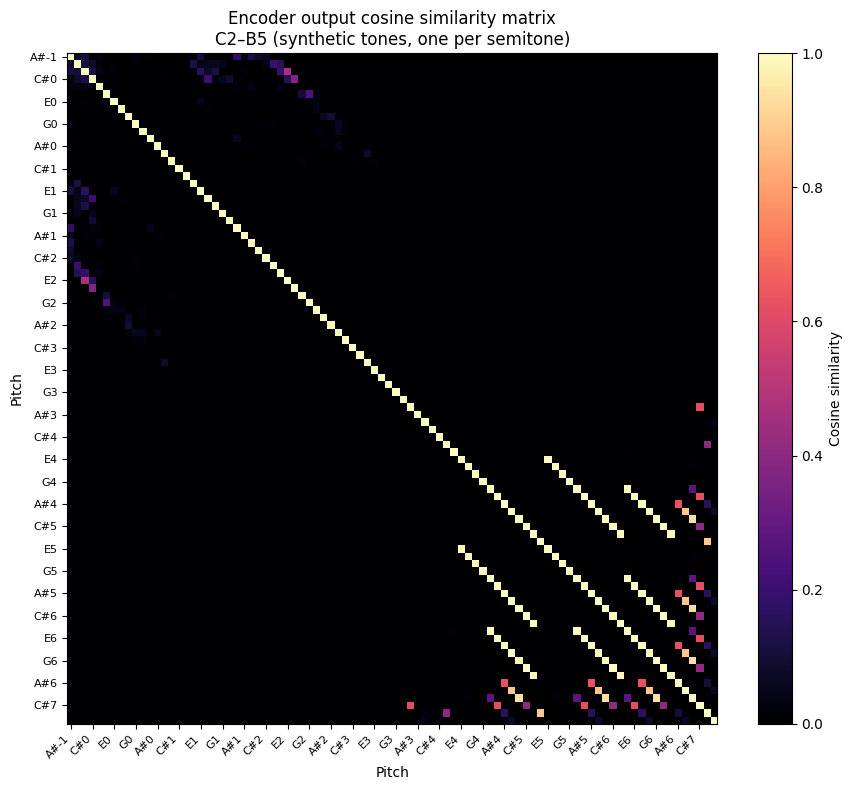

In [ ]:
model.eval()

notes      = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
midi_range = list(range(10, 100))   # C2 to B5, 48 pitches
SR_SYNTH   = 16000

# generate one synthetic tone per semitone and run through encoder
activation_per_pitch = []

with torch.no_grad():
    for midi in midi_range:
        audio   = generate_synth_data(midi, sr=SR_SYNTH)
        cqt_raw = datamodule.cqt(audio, SR_SYNTH)                              # (T, 1, freq_bins, 2)
        log_cqt = ToLogMagnitude()(torch.view_as_complex(cqt_raw.float()))     # (T, 1, freq_bins)
        log_cqt = log_cqt.to(device)

        # crop to encoder input width (same as model.pitch_shift does)
        lower_bin     = model.pitch_shift.lower_bin
        x = log_cqt[:, :, lower_bin : lower_bin + N_BINS_IN]

        acts = model.encoder(x)          # (T, output_dim)
        # average over time frames to get one vector per pitch
        activation_per_pitch.append(acts.mean(dim=0))

# stack into (n_pitches, output_dim) and compute cosine similarity matrix
A   = torch.stack(activation_per_pitch)                    # (48, output_dim)
A_n = F.normalize(A, dim=-1)                               # L2-normalise each row
sim = (A_n @ A_n.T).cpu().numpy()                          # (48, 48) cosine similarity

# tick labels: note name + octave, every 3 semitones to avoid crowding
tick_positions = list(range(0, len(midi_range), 3))
tick_labels    = [f"{notes[m % 12]}{m // 12 - 1}" for m in [midi_range[i] for i in tick_positions]]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(sim, origin='upper', cmap='magma', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_xticks(tick_positions); ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(tick_positions); ax.set_yticklabels(tick_labels, fontsize=8)
ax.set_xlabel('Pitch')
ax.set_ylabel('Pitch')
ax.set_title('Encoder output cosine similarity matrix\nC2–B5 (synthetic tones, one per semitone)')
plt.tight_layout()
plt.show()

### ToeplitzLinear weight matrix: before and after training
Since `Conv1d` only stores the kernel vector, the full Toeplitz matrix never exists in memory during the forward pass. We reconstruct it explicitly here by placing the kernel along every diagonal of a `(output_dim, N_BINS_IN)` matrix, giving us something we can directly visualise.

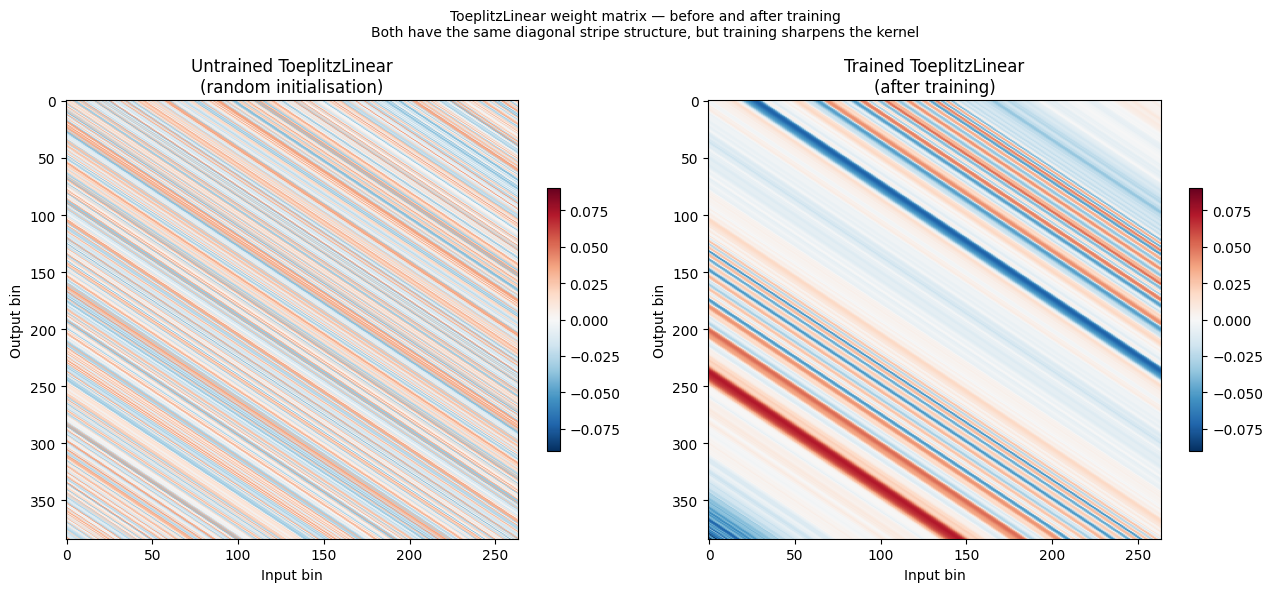

In [ ]:
# trained matrix — extract kernel from the model
trained_kernel   = model.encoder.fc.weight.data.squeeze().cpu().numpy()
W_trained        = kernel_to_toeplitz(trained_kernel, N_BINS_IN, OUTPUT_DIM)

# untrained matrix — fresh random initialisation, same dimensions
untrained_fc     = ToeplitzLinear(N_BINS_IN, OUTPUT_DIM)
untrained_kernel = untrained_fc.weight.data.squeeze().cpu().numpy()
W_untrained      = kernel_to_toeplitz(untrained_kernel, N_BINS_IN, OUTPUT_DIM)

# use a shared colour scale so the two panels are directly comparable
vmax = max(np.abs(W_trained).max(), np.abs(W_untrained).max())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

im0 = axes[0].imshow(W_untrained, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im0, ax=axes[0], shrink=0.6)
axes[0].set_xlabel('Input bin')
axes[0].set_ylabel('Output bin')
axes[0].set_title('Untrained ToeplitzLinear\n(random initialisation)')

im1 = axes[1].imshow(W_trained, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im1, ax=axes[1], shrink=0.6)
axes[1].set_xlabel('Input bin')
axes[1].set_ylabel('Output bin')
axes[1].set_title('Trained ToeplitzLinear\n(after training)')

plt.suptitle('ToeplitzLinear weight matrix: before and after training',
             fontsize=10)
plt.tight_layout()
plt.show()